# US Pollution Project
The data set for this project consists of data about pollution levels in different cities in the US. There are a number of different pollutants included in the data set. For more information, check out the Kaggle page below.

This data was sourced from https://www.kaggle.com/alpacanonymous/us-pollution-20002021.


In [ ]:
#@title Load your dataset
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os

pd.set_option('display.max_rows', 200)

!wget -q --show-progress "https://storage.googleapis.com/inspirit-ai-data-bucket-1/Data/AI%20%2B%20X/Group/Environment/Pollution/pollution_2000_2021.csv"
pollution_data = pd.read_csv('pollution_2000_2021.csv')

pollution_2000_2021 100%[===================>]  93.23M   172MB/s    in 0.5s    


# Dataset

In [ ]:
pollution_data.head()

,Date,Year,Month,Day,Address,State,County,City,O3 Mean,O3 1st Max Value,...,CO 1st Max Hour,CO AQI,SO2 Mean,SO2 1st Max Value,SO2 1st Max Hour,SO2 AQI,NO2 Mean,NO2 1st Max Value,NO2 1st Max Hour,NO2 AQI
0,2000-01-01,2000,1,1,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,0.019765,0.040,...,23,25.0,3.000000,9.0,21,13.0,19.041667,49.0,19,46
1,2000-01-02,2000,1,2,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,0.015882,0.032,...,0,26.0,1.958333,3.0,22,4.0,22.958333,36.0,19,34
2,2000-01-03,2000,1,3,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,0.009353,0.016,...,8,28.0,5.250000,11.0,19,16.0,38.125000,51.0,8,48
3,2000-01-04,2000,1,4,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,0.015882,0.033,...,23,34.0,7.083333,16.0,8,23.0,40.260870,74.0,8,72
4,2000-01-05,2000,1,5,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,0.007353,0.012,...,2,42.0,8.708333,15.0,7,21.0,48.450000,61.0,22,58


##Data Counting
###1 Count the total number of datapoints for each City
###2 Count the total number of datapoints by Year


In [ ]:
pollution_data['State'].value_counts()

California              187403
Pennsylvania             52026
Texas                    36457
Arizona                  23183
New York                 21383
Virginia                 18356
Colorado                 14254
Illinois                 13607
North Carolina           12992
Hawaii                   11703
Ohio                     11667
Maryland                 11125
Oklahoma                 10916
Arkansas                 10841
New Jersey               10598
Iowa                     10063
Connecticut               9739
Kansas                    9318
Maine                     9207
District Of Columbia      9128
Missouri                  8739
Utah                      8701
Florida                   8221
Louisiana                 7867
Massachusetts             7115
Nevada                    5738
Kentucky                  5321
Indiana                   5247
Wyoming                   4945
Oregon                    4597
North Dakota              4590
South Dakota              4015
New Hamp

In [ ]:
pollution_data.columns

Index(['Date', 'Year', 'Month', 'Day', 'Address', 'State', 'County', 'City',
       'O3 Mean', 'O3 1st Max Value', 'O3 1st Max Hour', 'O3 AQI', 'CO Mean',
       'CO 1st Max Value', 'CO 1st Max Hour', 'CO AQI', 'SO2 Mean',
       'SO2 1st Max Value', 'SO2 1st Max Hour', 'SO2 AQI', 'NO2 Mean',
       'NO2 1st Max Value', 'NO2 1st Max Hour', 'NO2 AQI'],
      dtype='object')

In [ ]:
pollution_data.groupby(['Year'])['City'].agg('count').reset_index().sort_values(by='City', ascending = False)


,Year,City
13,2013,33508
14,2014,32783
12,2012,32013
11,2011,31990
19,2019,31596
15,2015,31492
20,2020,31419
16,2016,31164
18,2018,30839
17,2017,30563


In [ ]:
pollution_data.shape

(608699, 24)

In [ ]:
np.sum(pollution_data.isnull())

Date                 0
Year                 0
Month                0
Day                  0
Address              0
State                0
County               0
City                 0
O3 Mean              0
O3 1st Max Value     0
O3 1st Max Hour      0
O3 AQI               0
CO Mean              0
CO 1st Max Value     0
CO 1st Max Hour      0
CO AQI               0
SO2 Mean             0
SO2 1st Max Value    0
SO2 1st Max Hour     0
SO2 AQI              0
NO2 Mean             0
NO2 1st Max Value    0
NO2 1st Max Hour     0
NO2 AQI              0
dtype: int64

# Data Grouping

In [ ]:
pollution_data = pollution_data[pollution_data['Year']>2001]

In [ ]:
def get_categorical_year():
  year_categorical_features = []
  for i, row in pollution_data.iterrows():
    year = row['Year']
    if 2006 >= year >= 2002:
      category = '2002-2006'
    elif 2011 >= year >= 2007:
      category = '2007-2011'
    elif 2016 >= year >= 2012:
      category = '2012-2016'
    elif 2021 >= year >= 2017:
      category = '2017-2021'
    year_categorical_features.append(category)
  return year_categorical_features

year_categorical_features = get_categorical_year()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(year_categorical_features)
year_numerical_features = le.transform(year_categorical_features)

In [ ]:
pollution_data['Year Grouping'] = year_numerical_features.tolist()

In [ ]:
print(year_numerical_features)

[0 0 0 ... 3 3 3]


In [ ]:
pollution_data['Year Grouping'].value_counts()

2    160960
3    143866
1    140680
0    116524
Name: Year Grouping, dtype: int64

In [ ]:
len(year_numerical_features)

562030

In [ ]:
def get_categorical_state():
  state_categorical_features = []
  for i, row in pollution_data.iterrows():
    state = row['State']
    if state == "Connecticut" or state == "Maine" or state == "Massachusetts" or state == "New Hampshire" or state == "Rhode Island" or state == "Vermont" or state == "New Jersey" or state == "New York" or state == "Pennsylvania":
      category = "northeast"
    elif state == "Illinois" or state == "Indiana" or state == "Michigan" or state == "Ohio" or state == "Wisconsin" or state == "Iowa" or state == "Kansas" or state == "Minnesota" or state == "Missouri" or state == "Nebraska" or state == "North Dakota" or state == "South Dakota":
      category = "midwest"
    elif state == "Delaware" or state == "Florida" or state == "Georgia" or state == "Maryland" or state == "North Carolina" or state == "South Carolina" or state == "Virginia" or state == "Washington, D.C." or state == "West Virginia" or state == "Alabama" or state == "Kentucky" or state == "Mississippi" or state == "Tennessee" or state == "Arkansas" or state == "Louisiana" or state == "Oklahoma" or state == "Texas":
      category = "south"
    else:
      category = "west"
    #elif state == "Arizona" or "Colorado" or "Idaho" or "Montana" or "Nevada" or "New Mexico" or "Utah" or "Wyoming" or "Alaska" or "California" or "Hawaii" or "Oregon" or "Washington":
      #category = "west"
    state_categorical_features.append(category)
    #print(state_categorical_features)
  return state_categorical_features

state_categorical_features = get_categorical_state()

In [ ]:
from sklearn.preprocessing import LabelEncoder
leb = LabelEncoder()
leb.fit(state_categorical_features)
state_numerical_features = leb.transform(state_categorical_features)

In [ ]:
print(state_numerical_features)

[3 3 3 ... 3 3 3]


In [ ]:
len(state_numerical_features)

562030

In [ ]:
pollution_data['State Grouping'] = state_numerical_features.tolist()

In [ ]:
pollution_data['State Grouping'].value_counts()

3    257216
2    126918
1    110159
0     67737
Name: State Grouping, dtype: int64

In [ ]:
pollution_data.head()

,Date,Year,Month,Day,Address,State,County,City,O3 Mean,O3 1st Max Value,...,SO2 Mean,SO2 1st Max Value,SO2 1st Max Hour,SO2 AQI,NO2 Mean,NO2 1st Max Value,NO2 1st Max Hour,NO2 AQI,Year Grouping,State Grouping
46669,2002-01-01,2002,1,1,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,0.012000,0.021,...,6.208333,9.0,9,13.0,32.791667,50.0,20,47,0,3
46670,2002-01-02,2002,1,2,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,0.011118,0.023,...,4.666667,8.0,7,11.0,25.916667,40.0,7,38,0,3
46671,2002-01-03,2002,1,3,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,0.009647,0.023,...,8.833333,15.0,6,21.0,38.136364,58.0,9,55,0,3
46672,2002-01-04,2002,1,4,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,0.009000,0.019,...,7.375000,12.0,0,17.0,33.541667,51.0,0,48,0,3
46673,2002-01-05,2002,1,5,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,0.009529,0.022,...,8.916667,14.0,7,20.0,38.791667,53.0,19,50,0,3


In [ ]:
pollution_region_northeast = pollution_data[pollution_data['State Grouping'] == 0]
pollution_region_midwest = pollution_data[pollution_data['State Grouping'] == 1]
pollution_region_south = pollution_data[pollution_data['State Grouping'] == 2]
pollution_region_west = pollution_data[pollution_data['State Grouping'] == 3]

In [ ]:
len(pollution_region_northeast)

67737

In [ ]:
len(pollution_region_midwest)

110159

In [ ]:
len(pollution_region_south)

126918

In [ ]:
len(pollution_region_west)

257216

In [ ]:
print(pollution_data['CO AQI'])

46669     34.0
46670     16.0
46671     28.0
46672     23.0
46673     27.0
          ... 
608694     1.0
608695     1.0
608696     1.0
608697     1.0
608698     1.0
Name: CO AQI, Length: 562030, dtype: float64


In [ ]:
type(pollution_region_northeast)

pandas.core.frame.DataFrame

# Graphs

In [ ]:
import matplotlib


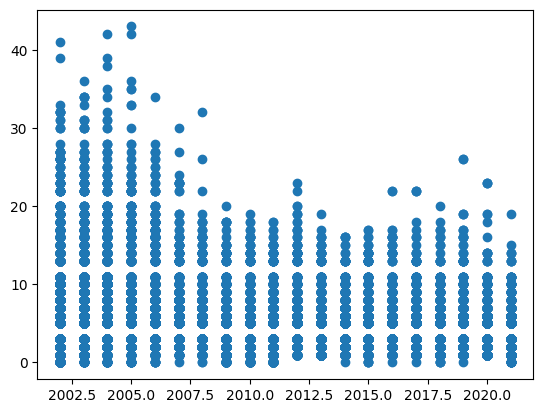

In [ ]:
matplotlib.pyplot.scatter(pollution_region_northeast['Year'], pollution_region_northeast['CO AQI'])


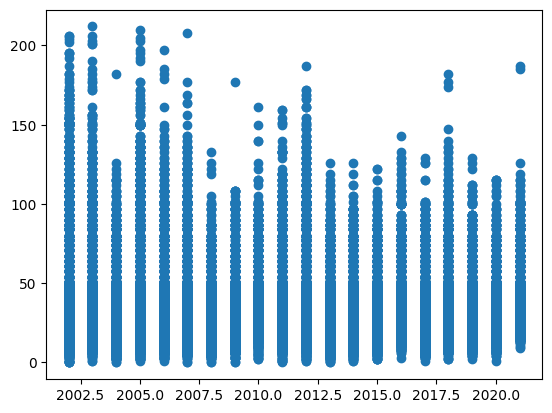

In [ ]:
matplotlib.pyplot.scatter(pollution_region_northeast['Year'], pollution_region_northeast['O3 AQI'])


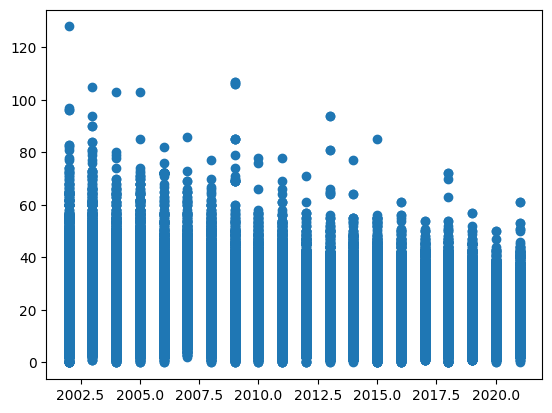

In [ ]:
matplotlib.pyplot.scatter(pollution_region_northeast['Year'], pollution_region_northeast['NO2 AQI'])


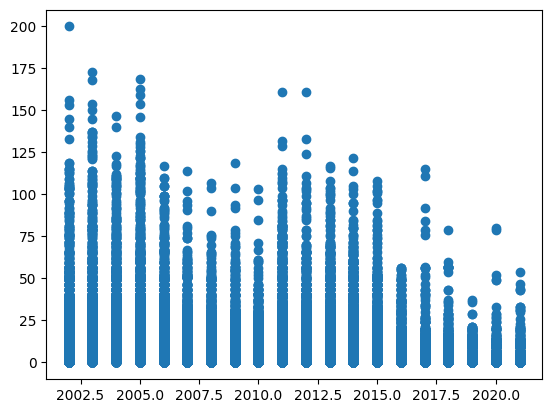

In [ ]:
matplotlib.pyplot.scatter(pollution_region_northeast['Year'], pollution_region_northeast['SO2 AQI'])


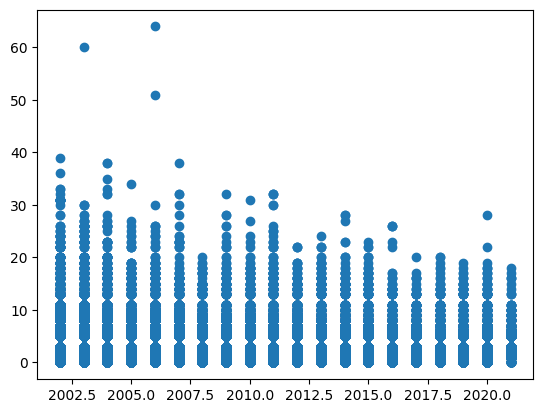

In [ ]:
matplotlib.pyplot.scatter(pollution_region_midwest['Year'], pollution_region_midwest['CO AQI'])


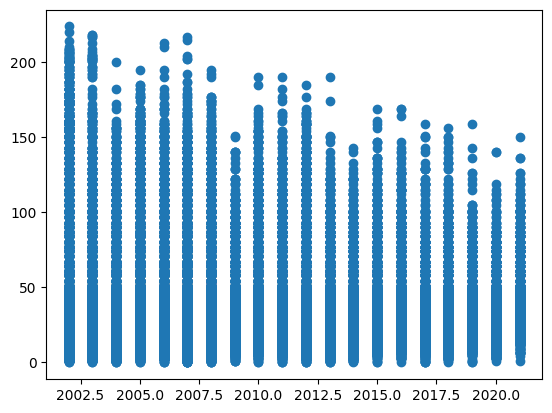

In [ ]:
matplotlib.pyplot.scatter(pollution_region_midwest['Year'], pollution_region_midwest['O3 AQI'])


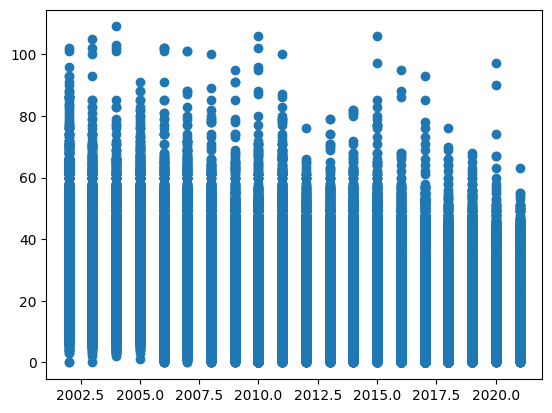

In [ ]:
matplotlib.pyplot.scatter(pollution_region_midwest['Year'], pollution_region_midwest['NO2 AQI'])


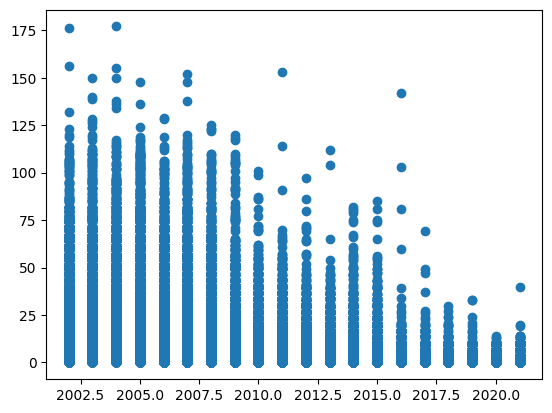

In [ ]:
matplotlib.pyplot.scatter(pollution_region_midwest['Year'], pollution_region_midwest['SO2 AQI'])


# Append numerical features to original dataset by converting array to a list. See: https://www.statology.org/add-numpy-array-to-pandas-dataframe/
pollution_data['Year Grouping (0=2002-2006, 1=2007-2011, 2=2012-2016, 3=2017-2021)'] = year_numerical_features.tolist()

# Model Development

In [ ]:
# Error Metrics
# (1) Mean Absolute Error
# (2) ***Mean Squared Error
# (3) R2 (coefficient of determination) (score)
# (4)Bonus: Root mean squared error:
# rms = sqrt(mean_squared_error(y_actual, y_predicted))

###northeast, CO

In [ ]:
y_northeast_CO = pollution_region_northeast['CO AQI']
X_northeast = pollution_region_northeast['Year']

In [ ]:
from sklearn.model_selection import train_test_split
X_northeast_train, X_northeast_test, y_northeast_CO_train, y_northeast_CO_test = train_test_split(X_northeast, y_northeast_CO, test_size=0.2)

In [ ]:
X_northeast_train_df = X_northeast_train.to_frame()
y_northeast_CO_train_df = y_northeast_CO_train.to_frame()
X_northeast_test_df = X_northeast_test.to_frame()
y_northeast_CO_test_df = y_northeast_CO_test.to_frame()

In [ ]:
from sklearn.linear_model import LinearRegression
regression_model = LinearRegression()
regression_model.fit(X_northeast_train_df, y_northeast_CO_train_df)
predictions_northeast_CO = regression_model.predict(X_northeast_test_df)

In [ ]:
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_northeast_CO_test_df, predictions_northeast_CO))

from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_northeast_CO_test_df, predictions_northeast_CO))

from sklearn.metrics import r2_score
print(r2_score(y_northeast_CO_test_df, predictions_northeast_CO))

2.203892680971634
10.68120739987288
0.20736986431290616


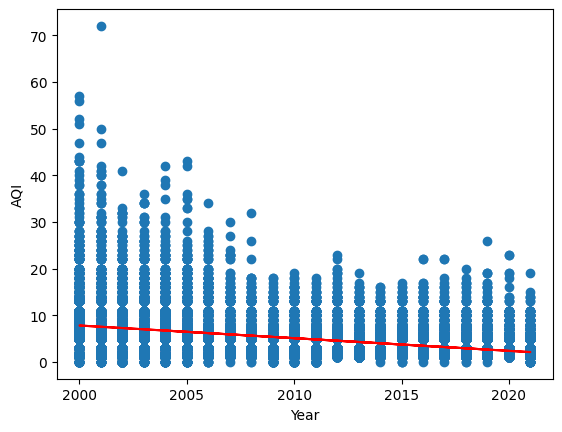

In [ ]:
plt.plot(X_northeast_test_df, predictions_northeast_CO, color='red')
plt.scatter(X_northeast_train_df, y_northeast_CO_train_df)
plt.xlabel('Year') # set the labels of the x and y axes
plt.ylabel('AQI')
plt.show()

### midwest, CO

In [ ]:
y_midwest_CO = pollution_region_midwest['CO AQI']
X_midwest = pollution_region_midwest['Year']

In [ ]:
from sklearn.model_selection import train_test_split
X_midwest_train, X_midwest_test, y_midwest_CO_train, y_midwest_CO_test = train_test_split(X_midwest, y_midwest_CO, test_size=0.2)

In [ ]:
X_midwest_train_df = X_midwest_train.to_frame()
y_midwest_CO_train_df = y_midwest_CO_train.to_frame()
X_midwest_test_df = X_midwest_test.to_frame()
y_midwest_CO_test_df = y_midwest_CO_test.to_frame()

In [ ]:
from sklearn.linear_model import LinearRegression
regression_model = LinearRegression()
regression_model.fit(X_midwest_train_df, y_midwest_CO_train_df)
predictions_midwest_CO = regression_model.predict(X_midwest_test_df)

In [ ]:
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_midwest_CO_test_df, predictions_midwest_CO))

from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_midwest_CO_test_df, predictions_midwest_CO))

from sklearn.metrics import r2_score
print(r2_score(y_midwest_CO_test_df, predictions_midwest_CO))

2.429633323358586
11.703384940123863
0.08129077285229847


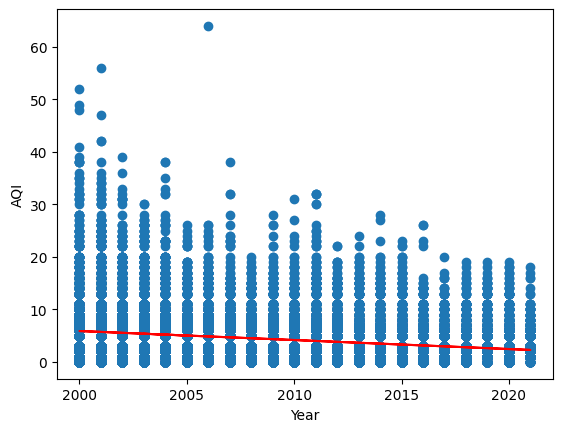

In [ ]:
plt.plot(X_midwest_test_df, predictions_midwest_CO, color='red')
plt.scatter(X_midwest_train_df, y_midwest_CO_train_df)
plt.xlabel('Year') # set the labels of the x and y axes
plt.ylabel('AQI')
plt.show()

### south, CO

In [ ]:
y_south_CO = pollution_region_south['CO AQI']
X_south = pollution_region_south['Year']

In [ ]:
from sklearn.model_selection import train_test_split
X_south_train, X_south_test, y_south_CO_train, y_south_CO_test = train_test_split(X_south, y_south_CO, test_size=0.2)

In [ ]:
X_south_train_df = X_south_train.to_frame()
y_south_CO_train_df = y_south_CO_train.to_frame()
X_south_test_df = X_south_test.to_frame()
y_south_CO_test_df = y_south_CO_test.to_frame()

In [ ]:
from sklearn.linear_model import LinearRegression
regression_model = LinearRegression()
regression_model.fit(X_south_train_df, y_south_CO_train_df)
predictions_south_CO = regression_model.predict(X_south_test_df)

In [ ]:
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_south_CO_test_df, predictions_south_CO))

from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_south_CO_test_df, predictions_south_CO))

from sklearn.metrics import r2_score
print(r2_score(y_south_CO_test_df, predictions_south_CO))

2.478301090294341
11.818140659610128
0.09510856134892665


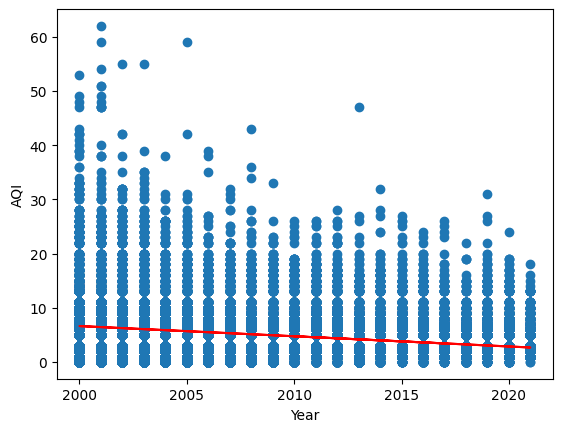

In [ ]:
plt.plot(X_south_test_df, predictions_south_CO, color='red')
plt.scatter(X_south_train_df, y_south_CO_train_df)
plt.xlabel('Year') # set the labels of the x and y axes
plt.ylabel('AQI')
plt.show()

### west, CO

In [ ]:
y_west_CO = pollution_region_west['CO AQI']
X_west = pollution_region_west['Year']

In [ ]:
from sklearn.model_selection import train_test_split
X_west_train, X_west_test, y_west_CO_train, y_west_CO_test = train_test_split(X_west, y_west_CO, test_size=0.2)

In [ ]:
X_west_train_df = X_west_train.to_frame()
y_west_CO_train_df = y_west_CO_train.to_frame()
X_west_test_df = X_west_test.to_frame()
y_west_CO_test_df = y_west_CO_test.to_frame()

In [ ]:
from sklearn.linear_model import LinearRegression
regression_model = LinearRegression()
regression_model.fit(X_west_train_df, y_west_CO_train_df)
predictions_west_CO = regression_model.predict(X_west_test_df)

In [ ]:
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_west_CO_test_df, predictions_west_CO))

from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_west_CO_test_df, predictions_west_CO))

from sklearn.metrics import r2_score
print(r2_score(y_west_CO_test_df, predictions_west_CO))

4.045175768753936
35.99239199847009
0.11044235444022765


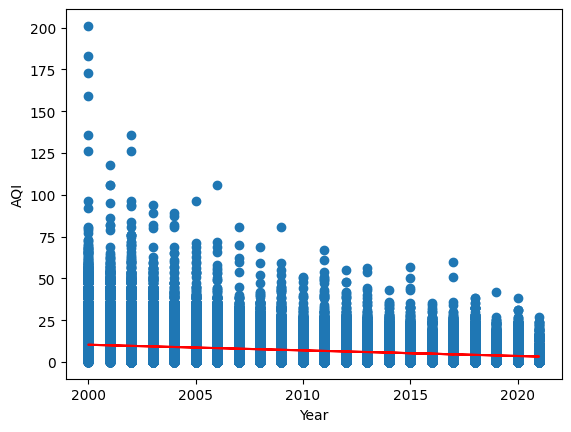

In [ ]:
plt.plot(X_west_test_df, predictions_west_CO, color='red')
plt.scatter(X_west_train_df, y_west_CO_train_df)
plt.xlabel('Year') # set the labels of the x and y axes
plt.ylabel('AQI')
plt.show()

### northeast, O3

In [ ]:
y_northeast_O3 = pollution_region_northeast['O3 AQI']
X_northeast = pollution_region_northeast['Year']

In [ ]:
from sklearn.model_selection import train_test_split
X_northeast_train, X_northeast_test, y_northeast_O3_train, y_northeast_O3_test = train_test_split(X_northeast, y_northeast_O3, test_size=0.2)

In [ ]:
X_northeast_train_df = X_northeast_train.to_frame()
y_northeast_O3_train_df = y_northeast_O3_train.to_frame()
X_northeast_test_df = X_northeast_test.to_frame()
y_northeast_O3_test_df = y_northeast_O3_test.to_frame()

In [ ]:
from sklearn.linear_model import LinearRegression
regression_model_northeast_O3 = LinearRegression()
regression_model_northeast_O3.fit(X_northeast_train_df, y_northeast_O3_train_df)
predictions_northeast_O3 = regression_model_northeast_O3.predict(X_northeast_test_df)

In [ ]:
regression_model_northeast_O3.coef_

array([[-0.44627414]])

In [ ]:
regression_model_northeast_O3.intercept_

array([934.64477914])

In [ ]:
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_northeast_O3_test_df, predictions_northeast_O3))

from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_northeast_O3_test_df, predictions_northeast_O3))

from sklearn.metrics import r2_score
print(r2_score(y_northeast_O3_test_df, predictions_northeast_O3))

13.098311721412509
378.71382344997284
0.019305425392916575


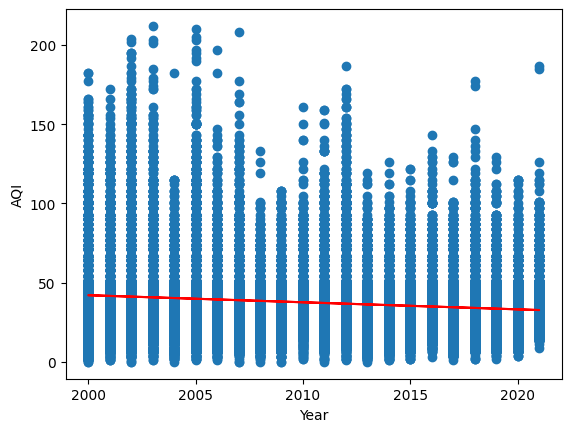

In [ ]:
plt.plot(X_northeast_test_df, predictions_northeast_O3, color='red')
plt.scatter(X_northeast_train_df, y_northeast_O3_train_df)
plt.xlabel('Year') # set the labels of the x and y axes
plt.ylabel('AQI')
plt.show()

###midwest, O3

In [ ]:
y_midwest_O3 = pollution_region_midwest['O3 AQI']
X_midwest = pollution_region_midwest['Year']

In [ ]:
from sklearn.model_selection import train_test_split
X_midwest_train, X_midwest_test, y_midwest_O3_train, y_midwest_O3_test = train_test_split(X_midwest, y_midwest_O3, test_size=0.2)

In [ ]:
X_midwest_train_df = X_midwest_train.to_frame()
y_midwest_O3_train_df = y_midwest_O3_train.to_frame()
X_midwest_test_df = X_midwest_test.to_frame()
y_midwest_O3_test_df = y_midwest_O3_test.to_frame()

In [ ]:
from sklearn.linear_model import LinearRegression
regression_model = LinearRegression()
regression_model.fit(X_midwest_train_df, y_midwest_O3_train_df)
predictions_midwest_O3 = regression_model.predict(X_midwest_test_df)

In [ ]:
regression_model.coef_

array([[-0.6204788]])

In [ ]:
regression_model.intercept_

array([1285.76415568])

In [ ]:
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_midwest_O3_test_df, predictions_midwest_O3))

from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_midwest_O3_test_df, predictions_midwest_O3))

from sklearn.metrics import r2_score
print(r2_score(y_midwest_O3_test_df, predictions_midwest_O3))

14.431208237370633
497.3373579759494
0.02102978865593197


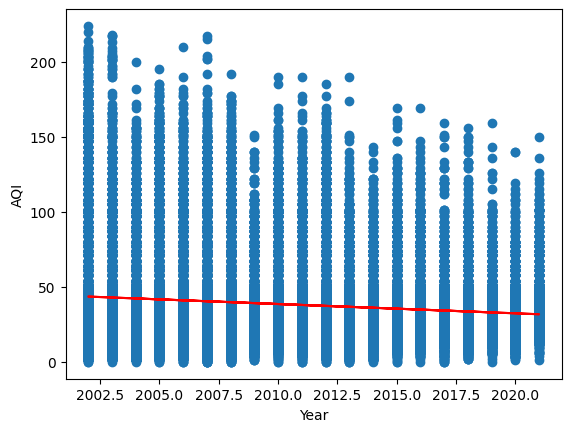

In [ ]:
plt.plot(X_midwest_test_df, predictions_midwest_O3, color='red')
plt.scatter(X_midwest_train_df, y_midwest_O3_train_df)
plt.xlabel('Year') # set the labels of the x and y axes
plt.ylabel('AQI')
plt.show()

### south, O3

In [ ]:
y_south_O3 = pollution_region_south['O3 AQI']
X_south = pollution_region_south['Year']

In [ ]:
from sklearn.model_selection import train_test_split
X_south_train, X_south_test, y_south_O3_train, y_south_O3_test = train_test_split(X_south, y_south_O3, test_size=0.2)

In [ ]:
X_south_train_df = X_south_train.to_frame()
y_south_O3_train_df = y_south_O3_train.to_frame()
X_south_test_df = X_south_test.to_frame()
y_south_O3_test_df = y_south_O3_test.to_frame()

In [ ]:
from sklearn.linear_model import LinearRegression
regression_model = LinearRegression()
regression_model.fit(X_south_train_df, y_south_O3_train_df)
predictions_south_O3 = regression_model.predict(X_south_test_df)

In [ ]:
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_south_O3_test_df, predictions_south_O3))

from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_south_O3_test_df, predictions_south_O3))

from sklearn.metrics import r2_score
print(r2_score(y_south_O3_test_df, predictions_south_O3))

14.681666429704856
491.58025839893776
0.027391493156314062


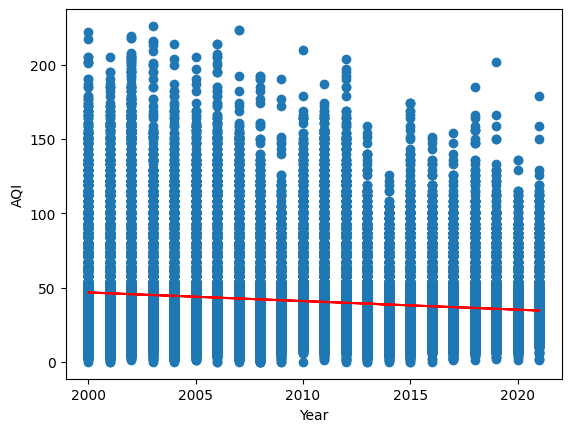

In [ ]:
plt.plot(X_south_test_df, predictions_south_O3, color='red')
plt.scatter(X_south_train_df, y_south_O3_train_df)
plt.xlabel('Year') # set the labels of the x and y axes
plt.ylabel('AQI')
plt.show()

### west, O3

In [ ]:
y_west_O3 = pollution_region_west['O3 AQI']
X_west = pollution_region_west['Year']

In [ ]:
from sklearn.model_selection import train_test_split
X_west_train, X_west_test, y_west_O3_train, y_west_O3_test = train_test_split(X_west, y_west_O3, test_size=0.2)

In [ ]:
X_west_train_df = X_west_train.to_frame()
y_west_O3_train_df = y_west_O3_train.to_frame()
X_west_test_df = X_west_test.to_frame()
y_west_O3_test_df = y_west_O3_test.to_frame()

In [ ]:
from sklearn.linear_model import LinearRegression
regression_model = LinearRegression()
regression_model.fit(X_west_train_df, y_west_O3_train_df)
predictions_west_O3 = regression_model.predict(X_west_test_df)

In [ ]:
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_west_O3_test_df, predictions_west_O3))

from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_west_O3_test_df, predictions_west_O3))

from sklearn.metrics import r2_score
print(r2_score(y_west_O3_test_df, predictions_west_O3))

14.421586574997173
513.8943536809675
0.0008855389956693438


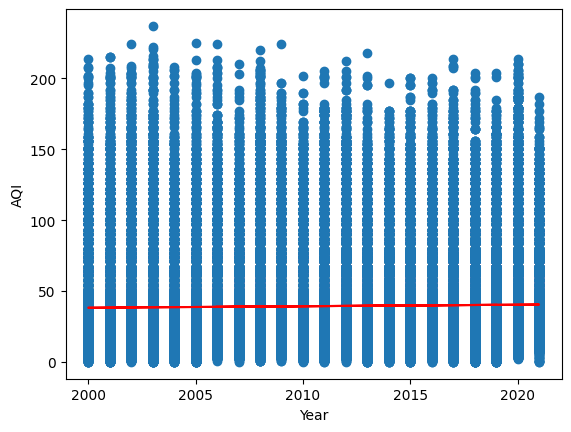

In [ ]:
plt.plot(X_west_test_df, predictions_west_O3, color='red')
plt.scatter(X_west_train_df, y_west_O3_train_df)
plt.xlabel('Year') # set the labels of the x and y axes
plt.ylabel('AQI')
plt.show()

### northeast, NO2

In [ ]:
y_northeast_NO2 = pollution_region_northeast['NO2 AQI']
X_northeast = pollution_region_northeast['Year']

In [ ]:
from sklearn.model_selection import train_test_split
X_northeast_train, X_northeast_test, y_northeast_NO2_train, y_northeast_NO2_test = train_test_split(X_northeast, y_northeast_NO2, test_size=0.2)

In [ ]:
X_northeast_train_df = X_northeast_train.to_frame()
y_northeast_NO2_train_df = y_northeast_NO2_train.to_frame()
X_northeast_test_df = X_northeast_test.to_frame()
y_northeast_NO2_test_df = y_northeast_NO2_test.to_frame()

In [ ]:
from sklearn.linear_model import LinearRegression
regression_model = LinearRegression()
regression_model.fit(X_northeast_train_df, y_northeast_NO2_train_df)
predictions_northeast_NO2 = regression_model.predict(X_northeast_test_df)

In [ ]:
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_northeast_NO2_test_df, predictions_northeast_NO2))

from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_northeast_NO2_test_df, predictions_northeast_NO2))

from sklearn.metrics import r2_score
print(r2_score(y_northeast_NO2_test_df, predictions_northeast_NO2))

9.248873827009218
134.19770289305453
0.1355384584966357


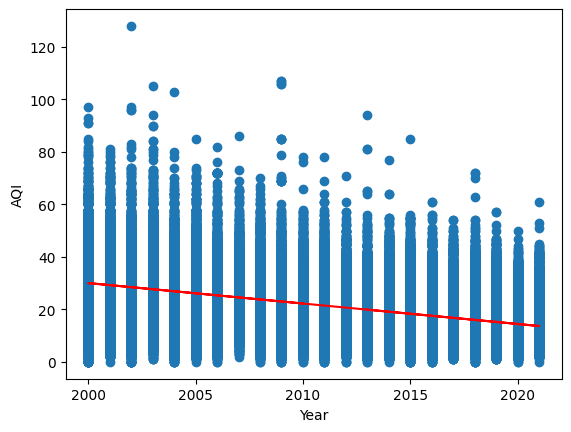

In [ ]:
plt.plot(X_northeast_test_df, predictions_northeast_NO2, color='red')
plt.scatter(X_northeast_train_df, y_northeast_NO2_train_df)
plt.xlabel('Year') # set the labels of the x and y axes
plt.ylabel('AQI')
plt.show()

###midwest, NO2

In [ ]:
y_midwest_NO2 = pollution_region_midwest['NO2 AQI']
X_midwest = pollution_region_midwest['Year']

In [ ]:
from sklearn.model_selection import train_test_split
X_midwest_train, X_midwest_test, y_midwest_NO2_train, y_midwest_NO2_test = train_test_split(X_midwest, y_midwest_NO2, test_size=0.2)

In [ ]:
X_midwest_train_df = X_midwest_train.to_frame()
y_midwest_NO2_train_df = y_midwest_NO2_train.to_frame()
X_midwest_test_df = X_midwest_test.to_frame()
y_midwest_NO2_test_df = y_midwest_NO2_test.to_frame()

In [ ]:
from sklearn.linear_model import LinearRegression
regression_model = LinearRegression()
regression_model.fit(X_midwest_train_df, y_midwest_NO2_train_df)
predictions_midwest_NO2 = regression_model.predict(X_midwest_test_df)

In [ ]:
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_midwest_NO2_test_df, predictions_midwest_NO2))

from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_midwest_NO2_test_df, predictions_midwest_NO2))

from sklearn.metrics import r2_score
print(r2_score(y_midwest_NO2_test_df, predictions_midwest_NO2))

10.040656585507616
158.04795160607557
0.13347527017417948


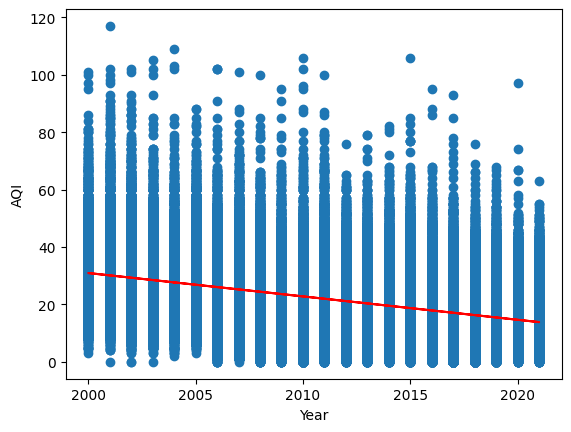

In [ ]:
plt.plot(X_midwest_test_df, predictions_midwest_NO2, color='red')
plt.scatter(X_midwest_train_df, y_midwest_NO2_train_df)
plt.xlabel('Year') # set the labels of the x and y axes
plt.ylabel('AQI')
plt.show()

### south, NO2

In [ ]:
y_south_NO2 = pollution_region_south['NO2 AQI']
X_south = pollution_region_south['Year']

In [ ]:
from sklearn.model_selection import train_test_split
X_south_train, X_south_test, y_south_NO2_train, y_south_NO2_test = train_test_split(X_south, y_south_NO2, test_size=0.2)

In [ ]:
X_south_train_df = X_south_train.to_frame()
y_south_NO2_train_df = y_south_NO2_train.to_frame()
X_south_test_df = X_south_test.to_frame()
y_south_NO2_test_df = y_south_NO2_test.to_frame()

In [ ]:
from sklearn.linear_model import LinearRegression
regression_model = LinearRegression()
regression_model.fit(X_south_train_df, y_south_NO2_train_df)
predictions_south_NO2 = regression_model.predict(X_south_test_df)

In [ ]:
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_south_NO2_test_df, predictions_south_NO2))

from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_south_NO2_test_df, predictions_south_NO2))

from sklearn.metrics import r2_score
print(r2_score(y_south_NO2_test_df, predictions_south_NO2))

9.6328470532368
141.10060695047477
0.12308848338403


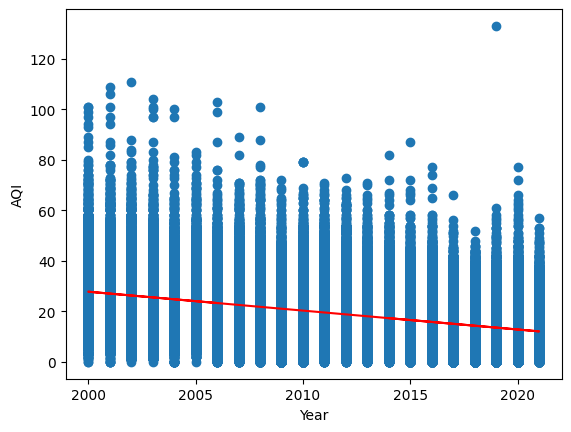

In [ ]:
plt.plot(X_south_test_df, predictions_south_NO2, color='red')
plt.scatter(X_south_train_df, y_south_NO2_train_df)
plt.xlabel('Year') # set the labels of the x and y axes
plt.ylabel('AQI')
plt.show()

### west, NO2

In [ ]:
y_west_NO2 = pollution_region_west['NO2 AQI']
X_west = pollution_region_west['Year']

In [ ]:
from sklearn.model_selection import train_test_split
X_west_train, X_west_test, y_west_NO2_train, y_west_NO2_test = train_test_split(X_west, y_west_NO2, test_size=0.2)

In [ ]:
X_west_train_df = X_west_train.to_frame()
y_west_NO2_train_df = y_west_NO2_train.to_frame()
X_west_test_df = X_west_test.to_frame()
y_west_NO2_test_df = y_west_NO2_test.to_frame()

In [ ]:
from sklearn.linear_model import LinearRegression
regression_model = LinearRegression()
regression_model.fit(X_west_train_df, y_west_NO2_train_df)
predictions_west_NO2 = regression_model.predict(X_west_test_df)

In [ ]:
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_west_NO2_test_df, predictions_west_NO2))

from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_west_NO2_test_df, predictions_west_NO2))

from sklearn.metrics import r2_score
print(r2_score(y_west_NO2_test_df, predictions_west_NO2))

12.808142746902611
247.67955926628127
0.05787996756229474


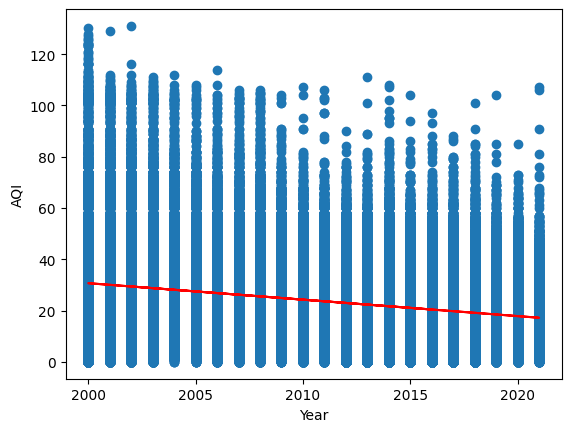

In [ ]:
plt.plot(X_west_test_df, predictions_west_NO2, color='red')
plt.scatter(X_west_train_df, y_west_NO2_train_df)
plt.xlabel('Year') # set the labels of the x and y axes
plt.ylabel('AQI')
plt.show()

###northeast, SO2

In [ ]:
y_northeast_SO2 = pollution_region_northeast['SO2 AQI']
X_northeast = pollution_region_northeast['Year']

In [ ]:
from sklearn.model_selection import train_test_split
X_northeast_train, X_northeast_test, y_northeast_SO2_train, y_northeast_SO2_test = train_test_split(X_northeast, y_northeast_SO2, test_size=0.2)

In [ ]:
X_northeast_train_df = X_northeast_train.to_frame()
y_northeast_SO2_train_df = y_northeast_SO2_train.to_frame()
X_northeast_test_df = X_northeast_test.to_frame()
y_northeast_SO2_test_df = y_northeast_SO2_test.to_frame()

In [ ]:
from sklearn.linear_model import LinearRegression
regression_model = LinearRegression()
regression_model.fit(X_northeast_train_df, y_northeast_SO2_train_df)
predictions_northeast_SO2 = regression_model.predict(X_northeast_test_df)

In [ ]:
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_northeast_SO2_test_df, predictions_northeast_SO2))

from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_northeast_SO2_test_df, predictions_northeast_SO2))

from sklearn.metrics import r2_score
print(r2_score(y_northeast_SO2_test_df, predictions_northeast_SO2))

7.6949363249698175
183.28943521601576
0.1435555991969948


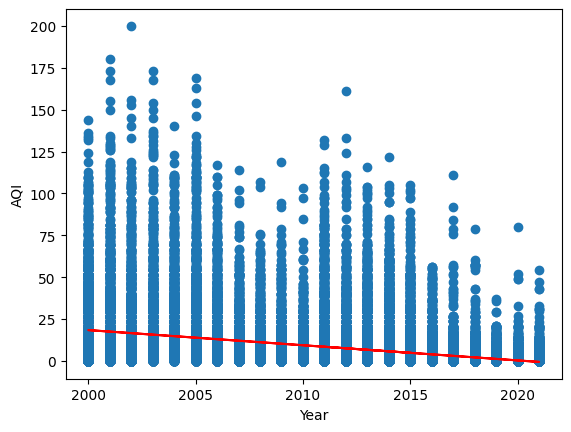

In [ ]:
plt.plot(X_northeast_test_df, predictions_northeast_SO2, color='red')
plt.scatter(X_northeast_train_df, y_northeast_SO2_train_df)
plt.xlabel('Year') # set the labels of the x and y axes
plt.ylabel('AQI')
plt.show()

### midwest, SO2

In [ ]:
y_midwest_SO2 = pollution_region_midwest['SO2 AQI']
X_midwest = pollution_region_midwest['Year']

In [ ]:
from sklearn.model_selection import train_test_split
X_midwest_train, X_midwest_test, y_midwest_SO2_train, y_midwest_SO2_test = train_test_split(X_midwest, y_midwest_SO2, test_size=0.2)

In [ ]:
X_midwest_train_df = X_midwest_train.to_frame()
y_midwest_SO2_train_df = y_midwest_SO2_train.to_frame()
X_midwest_test_df = X_midwest_test.to_frame()
y_midwest_SO2_test_df = y_midwest_SO2_test.to_frame()

In [ ]:
from sklearn.linear_model import LinearRegression
regression_model = LinearRegression()
regression_model.fit(X_midwest_train_df, y_midwest_SO2_train_df)
predictions_midwest_SO2 = regression_model.predict(X_midwest_test_df)

In [ ]:
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_midwest_SO2_test_df, predictions_midwest_SO2))

from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_midwest_SO2_test_df, predictions_midwest_SO2))

from sklearn.metrics import r2_score
print(r2_score(y_midwest_SO2_test_df, predictions_midwest_SO2))

7.525891021189198
144.3295309607398
0.2738472941930242


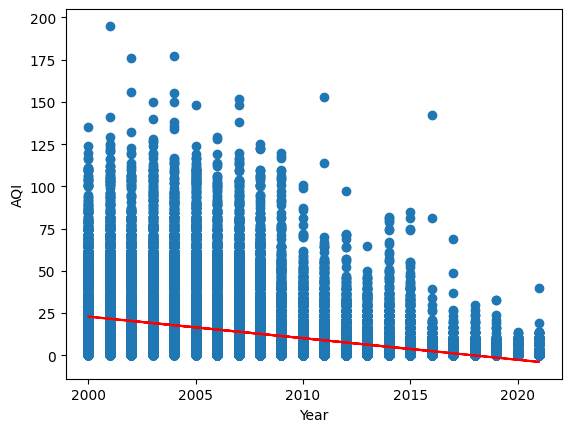

In [ ]:
plt.plot(X_midwest_test_df, predictions_midwest_SO2, color='red')
plt.scatter(X_midwest_train_df, y_midwest_SO2_train_df)
plt.xlabel('Year') # set the labels of the x and y axes
plt.ylabel('AQI')
plt.show()

### south, SO2

In [ ]:
y_south_SO2 = pollution_region_south['SO2 AQI']
X_south = pollution_region_south['Year']

In [ ]:
from sklearn.model_selection import train_test_split
X_south_train, X_south_test, y_south_SO2_train, y_south_SO2_test = train_test_split(X_south, y_south_SO2, test_size=0.2)

In [ ]:
X_south_train_df = X_south_train.to_frame()
y_south_SO2_train_df = y_south_SO2_train.to_frame()
X_south_test_df = X_south_test.to_frame()
y_south_SO2_test_df = y_south_SO2_test.to_frame()

In [ ]:
from sklearn.linear_model import LinearRegression
regression_model = LinearRegression()
regression_model.fit(X_south_train_df, y_south_SO2_train_df)
predictions_south_SO2 = regression_model.predict(X_south_test_df)

In [ ]:
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_south_SO2_test_df, predictions_south_SO2))

from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_south_SO2_test_df, predictions_south_SO2))

from sklearn.metrics import r2_score
print(r2_score(y_south_SO2_test_df, predictions_south_SO2))

5.231654602798105
87.84403744329357
0.1924536836487506


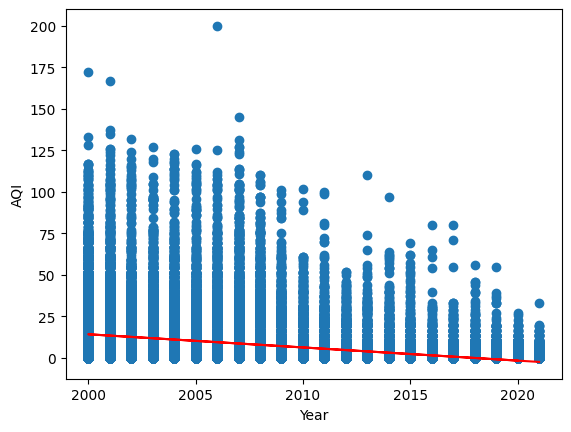

In [ ]:
plt.plot(X_south_test_df, predictions_south_SO2, color='red')
plt.scatter(X_south_train_df, y_south_SO2_train_df)
plt.xlabel('Year') # set the labels of the x and y axes
plt.ylabel('AQI')
plt.show()

### west, SO2

In [ ]:
y_west_SO2 = pollution_region_west['SO2 AQI']
X_west = pollution_region_west['Year']

In [ ]:
from sklearn.model_selection import train_test_split
X_west_train, X_west_test, y_west_SO2_train, y_west_SO2_test = train_test_split(X_west, y_west_SO2, test_size=0.2)

In [ ]:
X_west_train_df = X_west_train.to_frame()
y_west_SO2_train_df = y_west_SO2_train.to_frame()
X_west_test_df = X_west_test.to_frame()
y_west_SO2_test_df = y_west_SO2_test.to_frame()

In [ ]:
from sklearn.linear_model import LinearRegression
regression_model = LinearRegression()
regression_model.fit(X_west_train_df, y_west_SO2_train_df)
predictions_west_SO2 = regression_model.predict(X_west_test_df)

In [ ]:
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_west_SO2_test_df, predictions_west_SO2))

from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_west_SO2_test_df, predictions_west_SO2))

from sklearn.metrics import r2_score
print(r2_score(y_west_SO2_test_df, predictions_west_SO2))

2.9357880975082207
28.93036291311283
0.13649400620872743


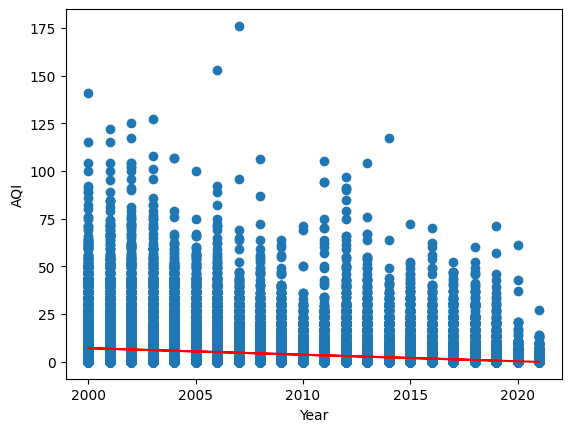

In [ ]:
plt.plot(X_west_test_df, predictions_west_SO2, color='red')
plt.scatter(X_west_train_df, y_west_SO2_train_df)
plt.xlabel('Year') # set the labels of the x and y axes
plt.ylabel('AQI')
plt.show()

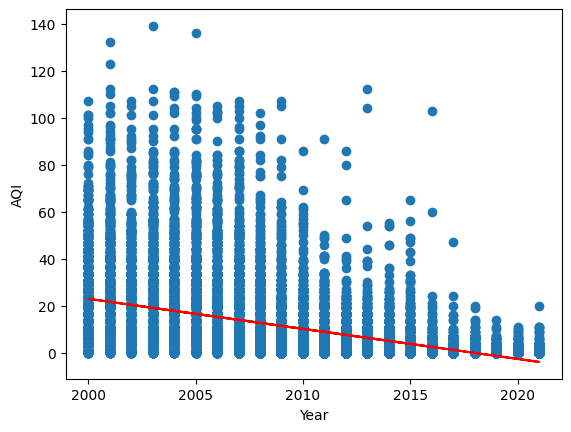

In [ ]:
#@title Visualize the fit with this cell!
import matplotlib.pyplot as plt

plt.plot(X_midwest_test_df, predictions_midwest_SO2, color='red')

plt.scatter(X_midwest_test_df, y_midwest_SO2_test_df)
plt.xlabel('Year') # set the labels of the x and y axes
plt.ylabel('AQI')
plt.show()